<a href="https://colab.research.google.com/github/dhfricard-coder/macro-regime-classifier/blob/main/01_setup_and_fred_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
!pip install fredapi pandas numpy scikit-learn hmmlearn plotly matplotlib

In [64]:
# I create this field ('FRED_API_KEY') to store key for FRED API
import os
os.environ["FRED_API_KEY"] = "76c0e4a342bf8acd26cbe7f30b2d38d8"

In [65]:
# I access FRED API
from fredapi import Fred
import pandas as pd
import numpy as np
import os

fred = Fred(api_key=os.getenv("FRED_API_KEY"))

In [66]:
# Check if i can import unemployment data
series = fred.get_series("UNRATE")
series.tail()

,0
2025-11-01,4.5
2025-12-01,4.4
2026-01-01,4.3
2026-02-01,4.4
2026-03-01,4.3


In [67]:
# PULL AND ENGINEER MACRO FEATURES
# Importing macro data from Federal Reserve Bank of St Louis (a very reliable source for Macro data)
data = {
    'cpi_yoy': fred.get_series('CPIAUCSL').pct_change(12)*100,
    'ism_mfg': fred.get_series('MANEMP'),
    'yield_curve': fred .get_series('T10Y2Y'), #high value sindicate steep curve and higher borrowing rates for long term bonds
    'real_rate' : fred.get_series('DFII10'), #borrowing rates adjuster per inflation. high values signal higher rates for borrowing. lower values cheap borrowing
    'credit_spread' : fred.get_series('BAMLH0A0HYM2'),
    'unemployment_chg' : fred.get_series('UNRATE').diff(3)
}

df = pd.DataFrame(data).dropna()
df.head()

/tmp/ipykernel_7529/927234819.py:3: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,cpi_yoy,ism_mfg,yield_curve,real_rate,credit_spread,unemployment_chg
2003-04-01,2.175125,14608.0,2.34,2.02,7.61,0.2
2003-05-01,1.894150,14558.0,2.38,2.13,6.37,0.2
2003-07-01,2.055556,14403.0,2.26,1.92,6.15,0.2
2003-08-01,2.216066,14376.0,2.59,2.40,5.77,0.0
2003-10-01,2.041943,14334.0,2.49,1.96,5.46,-0.2


In [68]:
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  
2025-04-01               0.2  
2025-05-01               0.1  
2025-07-01               0.1  
2025-08-01               0.0  
2025-12-01               0.0  
(176, 6)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

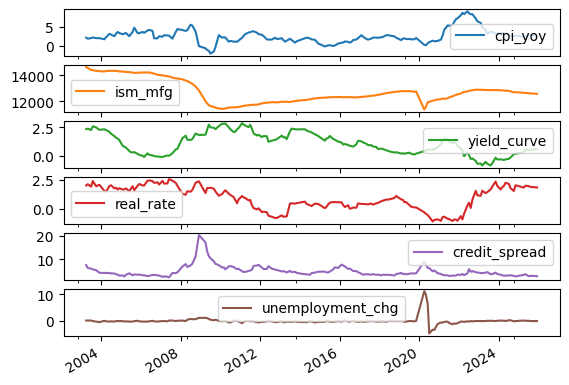

In [69]:
df.plot(subplots=True)

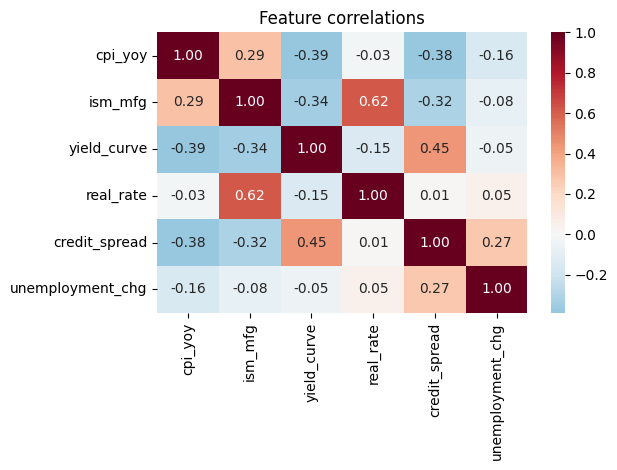

In [70]:
# Check Correlations
# Visualize pairwise correlations between features using a heatmap.
# - seaborn: provides a high-level, aesthetically pleasing heatmap
# - df.corr(): computes correlation matrix (linear relationships)
# - annot=True: display correlation values inside each cell
# - fmt='.2f': format values to 2 decimal places
# - cmap='RdBu_r': diverging color map (red = positive, blue = negative)
# - center=0: ensures colors are centered around zero correlation
# - matplotlib: used to add title and adjust layout for readability

import seaborn as sns #more automatic than matplot lib
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature correlations')
plt.tight_layout()

In [71]:
# BUILD THE REGIME CLASSIFIER
# Standardize features to have mean = 0 and standard deviation = 1.
# - StandardScaler learns the mean and std of each column (fit)
# - Then transforms the data using (x - mean) / std (transform)
# - This ensures all features are on the same scale, which is important for many ML models
# - Output is a NumPy array (not a DataFrame)from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X = scaler.fit_transform(df)

In [72]:
#Fit the GMM and assign regimes
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    n_init=10        # run 10 initialisations, pick the best
)
gmm.fit(X)

df['regime'] = gmm.predict(X)
df['regime_prob'] = gmm.predict_proba(X).max(axis=1)  # save the confidence score

In [73]:
# Interpret each regime
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  regime  regime_prob  
2025-04-01               0.2     1.0          1.0  
2025-05-01               0.1     1.0          1.0  
2025-07-01               0.1     1.0          1.0  
2025-08-01               0.0     1.0          1.0  
2025-12-01               0.0     1.0          1.0  
(176, 8)


In [74]:
#Map regimes
df.index = pd.to_datetime(df.index)
df = df.resample('MS').last()   # align to monthly
df = df.dropna()
print(df.tail())
print(df.shape)

             cpi_yoy  ism_mfg  yield_curve  real_rate  credit_spread  \
2025-04-01  2.325388  12662.0         0.30       1.84           3.50   
2025-05-01  2.377265  12651.0         0.55       2.00           3.78   
2025-07-01  2.742618  12625.0         0.48       1.97           2.91   
2025-08-01  2.938592  12615.0         0.54       1.90           3.13   
2025-12-01  2.653304  12580.0         0.55       1.85           2.94   

            unemployment_chg  regime  regime_prob  
2025-04-01               0.2     1.0          1.0  
2025-05-01               0.1     1.0          1.0  
2025-07-01               0.1     1.0          1.0  
2025-08-01               0.0     1.0          1.0  
2025-12-01               0.0     1.0          1.0  
(176, 8)


In [77]:
# Regime interpretation (based on macro feature averages):
# - Regime 1: Expansion / Risk-on → strong growth, improving labor market, low financial stress
# - Regime 0: Recovery / Early cycle → steep yield curve, low inflation, residual credit stress
# - Regime 3: Late cycle / Tightening → strong growth with high real rates, policy tightening, turning point
# - Regime 2: Recession / Risk-off → weak growth, rising unemployment, wide credit spreads, financial stress

# Cycle progression: Recovery → Expansion → Late Cycle → Recession

In [78]:
regime_map = {0: 'Recovery', 1: 'Expansion', 2: 'Recession', 3: 'Late Cycle'}
# adjust numbers based on what your clusters actually show
df['regime_label'] = df['regime'].map(regime_map)

In [79]:
#Regimes over time
import plotly.express as px
fig = px.scatter(df.reset_index(), x='index', y='cpi_yoy',
                 color='regime_label', title='Macro regimes over time (CPI YoY)')
fig.show()

In [ ]:
# MAP REGIMES TO ASSET RETURNS
#Pull asset return data

